# Effect sizes of pairwise invariance violations (original scales)

For every (scale × sample-pair) where the **full original item set** failed to reach and pass scalar invariance, this notebook quantifies how much the non-invariance distorts observed scores, using `hitop_cfa.dif_effect_sizes` (metric-model decomposition: uniform severity shift α via GLS projection; per-item non-uniform DIF dᵢ = ν̂ᵢ − λᵢα̂; signed item bias, dMACS, and net/gross sum-score bias, integrated over the focal group's latent distribution) — **with 95% CIs** simulated from the fit's robust parameter covariance.

Covers the HiTOP scales on all three sample pairs (val_gp, val_en, gp_en) and the PHQ/GAD/BAARS scales on gp_en plus the four wave comparisons. Fit-based only (no permutations). Outputs: `data/effect_sizes/`.

The final section runs **per-group EFAs** (`hitop_cfa.configural_efa_report`) for every violation that failed at **configural** — where the effect-size decomposition is weakest (the metric model approximates) and the real question is what differs structurally between the groups.

Caveat: where configural invariance already failed, the metric model is an approximation — treat those rows as order-of-magnitude quantifications (the `failed_at` column records each violation's level).

In [1]:
import os
for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_var, "1")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hitop_cfa import dif_effect_sizes
from hitop_cfa.scales import ORIG_ITEMS, OTHER_SCALES

dat_dir = Path('../data')
fin_dir = dat_dir / 'finaldata'
out_dir = dat_dir / 'effect_sizes'
out_dir.mkdir(exist_ok=True)
temp_path = out_dir / 'es_temp.csv'
FORMULAS = {**ORIG_ITEMS, **OTHER_SCALES}
def items_of(scale):
    return FORMULAS[scale].split('=~', 1)[1].strip().split(' + ')

In [2]:
# pair datasets. grid1st for the sample pairs (concat orders match the
# pipelines); gridall wave frames for the wave comparisons
data_val = pd.read_csv(fin_dir / 'dat_val.csv')
data_gp = pd.read_csv(fin_dir / 'dat_gp_grid1st_full.csv')
data_en = pd.read_csv(fin_dir / 'dat_en_grid1st_full.csv')
gp_all = pd.read_csv(fin_dir / 'dat_gp_gridall_full.csv')
en_all = pd.read_csv(fin_dir / 'dat_en_gridall_full.csv')

_other_items = [i for f in OTHER_SCALES.values()
                for i in f.split('=~', 1)[1].strip().split(' + ')]

def _wave_frame(df, wave, label):
    if wave == 1:
        out = df[_other_items].copy()
    else:
        out = df[[f'{i}_recontact' for i in _other_items]].copy()
        out.columns = _other_items
    out['whichdata'] = label
    return out

PAIR_DATA = {
    'val_gp': pd.concat([data_val, data_gp]),
    'val_en': pd.concat([data_val, data_en]),
    'gp_en': pd.concat([data_gp, data_en]),
    'gp1_gp2': pd.concat([_wave_frame(gp_all, 1, 'gp_t1'), _wave_frame(gp_all, 2, 'gp_t2')]),
    'en1_en2': pd.concat([_wave_frame(en_all, 1, 'en_t1'), _wave_frame(en_all, 2, 'en_t2')]),
    'gp1_en2': pd.concat([_wave_frame(gp_all, 1, 'gp_t1'), _wave_frame(en_all, 2, 'en_t2')]),
    'gp2_en1': pd.concat([_wave_frame(gp_all, 2, 'gp_t2'), _wave_frame(en_all, 1, 'en_t1')]),
}

## Collect the violations

A (scale, pair) counts as a violation when the recorded baseline shows the full item set not reaching+passing scalar (`pscalar` NaN or < .05); `failed_at` = the first failing level (configural counts as passed when the ladder continued via the secondary criteria).

In [3]:
LEVELS = ['pconfig', 'pthresholds', 'pmetric', 'pscalar']
LEVEL_NAMES = ['configural', 'thresholds', 'metric', 'scalar']

def failed_at(row):
    cfg_ok = (pd.notna(row.pconfig) and row.pconfig >= 0.05) or pd.notna(row.pthresholds)
    if not cfg_ok:
        return 'configural'
    for col, name in zip(LEVELS[1:], LEVEL_NAMES[1:]):
        p = getattr(row, col)
        if pd.isna(p) or p < 0.05:
            return name
    return None  # passed scalar

SOURCES = [
    (dat_dir / 'cfa' / 'orig_cfa_res.csv',
     {'V_GP': 'val_gp', 'V_EN': 'val_en', 'GP_EN': 'gp_en'}),
    (dat_dir / 'cfa_other_gp_en' / 'orig_cfa_res.csv', {'GP_EN': 'gp_en'}),
    (dat_dir / 'cfa_other_gp1_gp2' / 'orig_cfa_res.csv', {'GP1_GP2': 'gp1_gp2'}),
    (dat_dir / 'cfa_other_en1_en2' / 'orig_cfa_res.csv', {'EN1_EN2': 'en1_en2'}),
    (dat_dir / 'cfa_other_gp1_en2' / 'orig_cfa_res.csv', {'GP1_EN2': 'gp1_en2'}),
    (dat_dir / 'cfa_other_gp2_en1' / 'orig_cfa_res.csv', {'GP2_EN1': 'gp2_en1'}),
]

violations = []
for path, pairmap in SOURCES:
    if not path.exists():
        print(f'[skip] {path} not found')
        continue
    df = pd.read_csv(path)
    for r in df.itertuples():
        if r.pair not in pairmap:
            continue
        level = failed_at(r)
        if level is not None:
            violations.append(dict(scale=r.scale, pair=pairmap[r.pair],
                                   failed_at=level, source=str(path.parent.name)))
violations = pd.DataFrame(violations).drop_duplicates(subset=['scale', 'pair'])
print(f'{len(violations)} pairwise violations of original scales:')
print(violations.groupby(['pair', 'failed_at']).size().unstack(fill_value=0))
violations

49 pairwise violations of original scales:
failed_at  configural  metric  scalar  thresholds
pair                                             
en1_en2             1       0       0           0
gp1_en2             3       1       0           1
gp1_gp2             1       0       0           0
gp2_en1             4       0       0           0
gp_en               4       1       4           3
val_en              2       4       6           1
val_gp              5       3       3           2


,scale,pair,failed_at,source
0,anhedonic_depression,val_gp,configural,cfa
1,anhedonic_depression,val_en,metric,cfa
2,anhedonic_depression,gp_en,thresholds,cfa
3,anxious_worry,val_gp,thresholds,cfa
4,anxious_worry,val_en,metric,cfa
5,anxious_worry,gp_en,metric,cfa
6,appetite_gain,val_gp,metric,cfa
7,appetite_gain,val_en,scalar,cfa
8,appetite_gain,gp_en,scalar,cfa
9,appetite_loss,val_gp,thresholds,cfa


## Compute effect sizes (with 95% CIs) for every violation

In [4]:
per_item_all, summary_all = [], []
for v in violations.itertuples():
    print(f'--- {v.scale} x {v.pair} (failed at {v.failed_at}) ---', flush=True)
    try:
        per_item, s = dif_effect_sizes(v.scale, items_of(v.scale),
                                       PAIR_DATA[v.pair], temp_path)
    except Exception as exc:
        print(f'    ERROR: {exc!r}')
        summary_all.append(dict(scale=v.scale, pair=v.pair,
                                failed_at=v.failed_at, error=repr(exc)))
        continue
    if per_item is None:
        print('    metric model did not converge')
        summary_all.append(dict(scale=v.scale, pair=v.pair,
                                failed_at=v.failed_at, error='nonconverged'))
        continue
    per_item.insert(0, 'pair', v.pair)
    per_item.insert(0, 'scale', v.scale)
    per_item_all.append(per_item)
    summary_all.append(dict(
        scale=v.scale, pair=v.pair, failed_at=v.failed_at,
        n_items=len(per_item), scale_max=s['scale_max_points'],
        alpha=round(s['alpha'], 3),
        alpha_lo=round(s['alpha_ci'][0], 3), alpha_hi=round(s['alpha_ci'][1], 3),
        real_gap_pts=round(s['real_gap_points'], 2),
        net_bias_pts=round(s['net_sum_bias_points'], 2),
        net_lo=round(s['net_ci'][0], 2), net_hi=round(s['net_ci'][1], 2),
        gross_bias_pts=round(s['gross_abs_bias_points'], 2),
        gross_lo=round(s['gross_ci'][0], 2), gross_hi=round(s['gross_ci'][1], 2),
        max_dMACS=round(per_item.dMACS.max(), 3),
        max_dMACS_item=per_item.loc[per_item.dMACS.idxmax(), 'item'],
        error=None))

per_item_all = pd.concat(per_item_all, ignore_index=True)
summary = pd.DataFrame(summary_all)
per_item_all.to_csv(out_dir / 'gp_pairwise_dif_per_item.csv', index=False)
summary.to_csv(out_dir / 'pairwise_dif_summary.csv', index=False)
print(f'\nsaved {len(per_item_all)} item rows / {len(summary)} scale-pair summaries to {out_dir}')

--- anhedonic_depression x val_gp (failed at configural) ---


--- anhedonic_depression x val_en (failed at metric) ---


--- anhedonic_depression x gp_en (failed at thresholds) ---


--- anxious_worry x val_gp (failed at thresholds) ---


--- anxious_worry x val_en (failed at metric) ---


...

--- phq_sum x gp2_en1 (failed at configural) ---


--- gad_sum x gp2_en1 (failed at configural) ---


--- baars_inattention_sum x gp2_en1 (failed at configural) ---


--- baars_sct_sum x gp2_en1 (failed at configural) ---



saved 328 item rows / 49 scale-pair summaries to ../data/effect_sizes


In [5]:
pd.set_option('display.width', 250)
summary['net_pct'] = (summary.net_bias_pts / summary.scale_max * 100).round(1)
summary['gross_pct'] = (summary.gross_bias_pts / summary.scale_max * 100).round(1)
cols = ['scale', 'pair', 'failed_at', 'alpha', 'real_gap_pts',
        'net_bias_pts', 'net_lo', 'net_hi', 'net_pct',
        'gross_bias_pts', 'gross_pct', 'max_dMACS', 'max_dMACS_item']
summary.sort_values('gross_pct', ascending=False)[cols]

,scale,pair,failed_at,alpha,real_gap_pts,net_bias_pts,net_lo,net_hi,net_pct,gross_bias_pts,gross_pct,max_dMACS,max_dMACS_item
32,well_being,val_gp,metric,0.245,1.62,-0.16,-0.92,0.73,-0.5,1.54,5.1,0.300,hitop200
28,situational_phobia,gp_en,scalar,0.501,1.23,-0.01,-0.27,0.55,-0.1,0.77,5.1,0.286,hitop225
1,anhedonic_depression,val_en,metric,0.274,1.85,0.36,-0.16,0.96,1.2,1.42,4.7,0.279,hitop157
30,social_anxiety,val_en,configural,0.114,0.90,0.08,-0.83,1.03,0.3,1.36,4.5,0.340,hitop1
2,anhedonic_depression,gp_en,thresholds,1.041,8.39,0.20,-0.11,0.83,0.7,1.32,4.4,0.231,hitop84
33,well_being,val_en,configural,-0.638,-3.68,-0.18,-0.62,0.25,-0.6,1.30,4.3,0.320,hitop9
45,phq_sum,gp2_en1,configural,1.198,7.77,0.11,-0.13,0.63,0.5,0.99,4.1,0.347,phq_8
3,anxious_worry,val_gp,thresholds,-1.269,-5.77,-0.14,-0.51,0.14,-0.7,0.79,3.8,0.264,hitop248
23,separation_insecurity,val_en,scalar,-0.032,-0.19,-0.24,-0.62,0.17,-1.0,0.90,3.8,0.293,hitop113
35,phq_sum,gp_en,configural,1.112,7.04,0.18,-0.04,0.61,0.8,0.88,3.7,0.228,phq_7


In [6]:
# items whose DIF CI excludes zero -- the individually credible violations
sig = per_item_all[(per_item_all.d_lo > 0) | (per_item_all.d_hi < 0)]
print(f'{len(sig)} of {len(per_item_all)} item x pair DIF estimates have '
      f'95% CIs excluding zero:')
print(sig[['scale', 'pair', 'item', 'd', 'd_lo', 'd_hi',
           'signed_bias', 'dMACS']].round(3).to_string(index=False))

109 of 328 item x pair DIF estimates have 95% CIs excluding zero:
                  scale    pair            item      d   d_lo   d_hi  signed_bias  dMACS
   anhedonic_depression  val_gp         hitop84 -0.484 -0.673 -0.300       -0.224  0.226
   anhedonic_depression  val_gp        hitop123  0.427  0.191  0.636        0.148  0.223
   anhedonic_depression  val_gp        hitop157  0.195  0.038  0.345        0.103  0.103
   anhedonic_depression  val_en         hitop39 -0.169 -0.335 -0.014       -0.109  0.110
   anhedonic_depression  val_en         hitop77  0.198  0.046  0.369        0.159  0.154
   anhedonic_depression  val_en         hitop92  0.389  0.147  0.648        0.203  0.208
   anhedonic_depression  val_en         hitop93 -0.446 -0.626 -0.248       -0.214  0.216
   anhedonic_depression  val_en        hitop123  0.316  0.135  0.515        0.201  0.226
   anhedonic_depression  val_en        hitop157  0.471  0.185  0.735        0.265  0.279
   anhedonic_depression   gp_en         hito

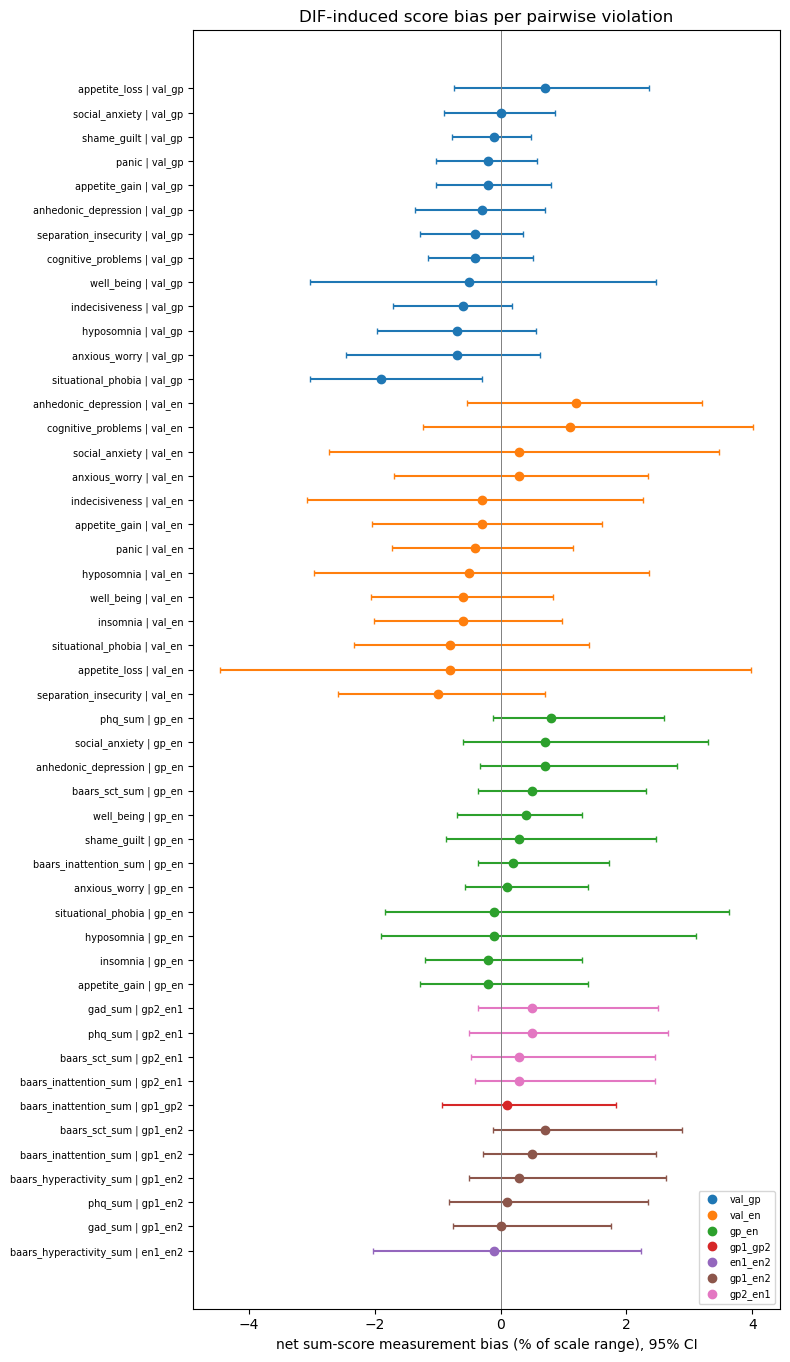

In [7]:
ok = summary[summary.error.isna()].copy()
ok['label'] = ok.scale + ' | ' + ok.pair
ok = ok.sort_values(['pair', 'net_pct'])
pair_colors = {p: c for p, c in zip(PAIR_DATA, plt.cm.tab10.colors)}
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(ok))))
y = np.arange(len(ok))
for j, r in enumerate(ok.itertuples()):
    lo = (r.net_bias_pts - r.net_lo) / r.scale_max * 100
    hi = (r.net_hi - r.net_bias_pts) / r.scale_max * 100
    ax.errorbar(r.net_pct, j, xerr=[[lo], [hi]], fmt='o',
                color=pair_colors[r.pair], capsize=2)
ax.axvline(0, color='gray', lw=0.7)
ax.set_yticks(y); ax.set_yticklabels(ok.label, fontsize=7)
ax.set_xlabel('net sum-score measurement bias (% of scale range), 95% CI')
ax.set_title('DIF-induced score bias per pairwise violation')
handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=p)
           for p, c in pair_colors.items() if p in set(ok.pair)]
ax.legend(handles=handles, fontsize=7, loc='lower right')
fig.tight_layout()

## Reading the table

- **α / real_gap_pts**: the genuine severity difference an invariant instrument would report (latent SD units / expected sum points).
- **net_bias_pts [net_lo, net_hi]**: the sum-score distortion caused by non-uniform DIF, on top of the real gap; `net_pct` scales it by the scale's range for cross-scale comparison. CIs containing zero = no credible *net* score bias despite the invariance failure (item effects cancel).
- **gross_bias_pts**: the sum of |item biases| — the distortion ceiling if items were used separately or reweighted (cancellation not guaranteed off the sum score).
- **max_dMACS / item**: the single worst item (Nye–Drasgow: ~.2 small, ~.4 medium, ~.7 large).
- Rows failing at **configural** carry the extra caveat that the metric model itself approximates.

## Per-group EFAs for the configural failures

For each (scale × pair) that failed at **configural**, both groups get: polychoric eigenvalues, the 1-factor WLSMV solution (fit, loadings, and the largest residual correlations — where unidimensional misfit concentrates), and a 2-factor geomin EFA when identified (≥ 5 items). What to look for: a second eigenvalue approaching 1 in one group but not the other; a 2-factor CFI improvement that is asymmetric across groups; and residual doublets naming the item clusters (cf. PHQ-8's somatic/affective split in the enriched sample).

In [8]:
from hitop_cfa import configural_efa_report

cfg_fails = violations[violations.failed_at == 'configural']
print(f'{len(cfg_fails)} configural failures to diagnose\n')

efa_summary = []
for v in cfg_fails.itertuples():
    print(f'================ {v.scale} x {v.pair} ================')
    try:
        res = configural_efa_report(v.scale, items_of(v.scale),
                                    PAIR_DATA[v.pair],
                                    out_dir / 'efa_temp.csv', verbose=True)
    except Exception as exc:
        print(f'   ERROR: {exc!r}')
        efa_summary.append(dict(scale=v.scale, pair=v.pair, error=repr(exc)))
        continue
    for label, r in res.items():
        eig = r['eigenvalues']
        row = dict(scale=v.scale, pair=v.pair, group=label, n=r['n'],
                   eig1=float(eig[0]), eig2=float(eig[1]),
                   eig2_over_eig1=round(float(eig[1] / eig[0]), 3),
                   error=None)
        if r['one_factor']:
            row['cfi_1f'] = round(r['one_factor']['fit']['cfi_robust'], 3)
            row['rmsea_1f'] = round(r['one_factor']['fit']['rmsea_robust'], 3)
            wr = r['one_factor']['worst_residuals'].iloc[0]
            row['worst_resid_pair'] = f"{wr.item1}~{wr.item2}"
            row['worst_resid'] = float(wr.resid)
        if r['two_factor']:
            row['cfi_2f'] = round(r['two_factor']['fit']['cfi_robust'], 3)
            row['rmsea_2f'] = round(r['two_factor']['fit']['rmsea_robust'], 3)
            row['cfi_gain_2f'] = round(row['cfi_2f'] - row.get('cfi_1f', float('nan')), 3)
        efa_summary.append(row)
    print()
efa_summary = pd.DataFrame(efa_summary)
efa_summary.to_csv(out_dir / 'configural_efa_summary.csv', index=False)
print(f'saved {len(efa_summary)} group rows to '
      f'{out_dir / "configural_efa_summary.csv"}')

20 configural failures to diagnose

================ anhedonic_depression x val_gp ================
----- anhedonic_depression | group: validation -----


  n = 496; polychoric eigenvalues: [5.66  0.86  0.788 0.66  0.506 0.427 0.358 0.333 0.231 0.177]
  1-factor: chisq 285.0 (df 35, p 0.000), CFI 0.880, RMSEA 0.142
  loadings: {'hitop39': np.float64(0.728), 'hitop77': np.float64(0.585), 'hitop84': np.float64(0.78), 'hitop92': np.float64(0.82), 'hitop93': np.float64(0.875), 'hitop123': np.float64(0.682), 'hitop157': np.float64(0.746), 'hitop182': np.float64(0.772), 'hitop230': np.float64(0.722), 'hitop246': np.float64(0.539)}
  worst residual correlations:
   item1    item2  resid
 hitop92  hitop39 -0.152
hitop157  hitop39 -0.135
hitop157  hitop92  0.129
hitop246 hitop123  0.123
 hitop93  hitop39  0.123
  2-factor geomin: chisq 114.3 (df 26), CFI 0.953, RMSEA 0.103
             f1     f2
hitop39   0.874 -0.025
hitop77   0.179  0.473
hitop84   0.272  0.598
hitop92  -0.009  0.896
hitop93   0.691  0.307
hitop123  0.467  0.310
hitop157 -0.036  0.823
hitop182  0.371  0.500
hitop230  0.300  0.509
hitop246  0.284  0.325
----- anhedonic_depressio

  n = 497; polychoric eigenvalues: [7.063 0.622 0.466 0.437 0.323 0.297 0.255 0.232 0.173 0.132]
  1-factor: chisq 146.7 (df 35, p 0.000), CFI 0.948, RMSEA 0.116
  loadings: {'hitop39': np.float64(0.874), 'hitop77': np.float64(0.74), 'hitop84': np.float64(0.852), 'hitop92': np.float64(0.871), 'hitop93': np.float64(0.901), 'hitop123': np.float64(0.781), 'hitop157': np.float64(0.8), 'hitop182': np.float64(0.866), 'hitop230': np.float64(0.826), 'hitop246': np.float64(0.72)}
  worst residual correlations:
   item1    item2  resid
hitop246 hitop157 -0.109
hitop157  hitop77 -0.086
hitop157  hitop92  0.086
hitop157 hitop123 -0.081
hitop230 hitop157 -0.054
  2-factor EFA did not converge

================ hyposomnia x val_gp ================
----- hyposomnia | group: validation -----


  n = 496; polychoric eigenvalues: [3.653 0.487 0.397 0.27  0.193]
  1-factor: chisq 32.0 (df 5, p 0.000), CFI 0.958, RMSEA 0.167
  loadings: {'hitop99': np.float64(0.831), 'hitop181': np.float64(0.847), 'hitop5': np.float64(0.719), 'hitop66': np.float64(0.826), 'hitop231': np.float64(0.873)}
  worst residual correlations:
   item1    item2  resid
hitop231  hitop66 -0.077
  hitop5  hitop99 -0.065
 hitop66  hitop99  0.044
hitop231 hitop181  0.035
hitop181  hitop99 -0.034
  2-factor EFA did not converge
----- hyposomnia | group: genpop -----


  n = 497; polychoric eigenvalues: [3.378 0.684 0.492 0.241 0.204]
  1-factor: chisq 76.2 (df 5, p 0.000), CFI 0.846, RMSEA 0.297
  loadings: {'hitop99': np.float64(0.786), 'hitop181': np.float64(0.837), 'hitop5': np.float64(0.855), 'hitop66': np.float64(0.751), 'hitop231': np.float64(0.713)}
  worst residual correlations:
   item1    item2  resid
  hitop5  hitop99 -0.147
hitop181  hitop99 -0.131
hitop231  hitop99  0.123
 hitop66  hitop99  0.089
hitop231 hitop181 -0.082
  2-factor EFA did not converge

================ panic x val_gp ================
----- panic | group: validation -----


...

  n = 255; polychoric eigenvalues: [4.362 0.944 0.649 0.41  0.285 0.24  0.11 ]
  1-factor: chisq 107.1 (df 14, p 0.000), CFI 0.900, RMSEA 0.184
  loadings: {'gad_1': np.float64(0.847), 'gad_2': np.float64(0.901), 'gad_3': np.float64(0.95), 'gad_4': np.float64(0.751), 'gad_5': np.float64(0.668), 'gad_6': np.float64(0.442), 'gad_7': np.float64(0.716)}
  worst residual correlations:
item1 item2  resid
gad_5 gad_4  0.185
gad_5 gad_3 -0.153
gad_5 gad_2 -0.139
gad_6 gad_5  0.137
gad_6 gad_2 -0.128
  2-factor geomin: chisq 7.3 (df 8), CFI 0.999, RMSEA 0.029
          f1     f2
gad_1  0.738  0.184
gad_2  0.933 -0.033
gad_3  0.963 -0.006
gad_4  0.344  0.562
gad_5 -0.009  0.912
gad_6  0.141  0.392
gad_7  0.675  0.086

================ baars_inattention_sum x gp2_en1 ================
----- baars_inattention_sum | group: gp_t2 -----


  n = 398; polychoric eigenvalues: [6.514 0.538 0.443 0.368 0.311 0.273 0.246 0.162 0.145]
  1-factor: chisq 77.1 (df 27, p 0.000), CFI 0.947, RMSEA 0.126
  loadings: {'inattention_1': np.float64(0.847), 'inattention_2': np.float64(0.869), 'inattention_3': np.float64(0.753), 'inattention_4': np.float64(0.842), 'inattention_5': np.float64(0.864), 'inattention_6': np.float64(0.86), 'inattention_7': np.float64(0.814), 'inattention_8': np.float64(0.828), 'inattention_9': np.float64(0.822)}
  worst residual correlations:
        item1         item2  resid
inattention_8 inattention_4 -0.114
inattention_5 inattention_3 -0.089
inattention_6 inattention_1 -0.072
inattention_8 inattention_6  0.065
inattention_7 inattention_3 -0.049
  2-factor geomin: chisq 41.4 (df 19), CFI 0.977, RMSEA 0.100
                  f1     f2
inattention_1  0.864 -0.083
inattention_2  0.848  0.102
inattention_3  0.730  0.109
inattention_4  0.903 -0.271
inattention_5  0.873 -0.048
inattention_6  0.823  0.185
inattentio

  n = 255; polychoric eigenvalues: [5.    0.862 0.746 0.62  0.484 0.43  0.364 0.273 0.221]
  1-factor: chisq 96.8 (df 27, p 0.000), CFI 0.902, RMSEA 0.129
  loadings: {'inattention_1': np.float64(0.682), 'inattention_2': np.float64(0.759), 'inattention_3': np.float64(0.594), 'inattention_4': np.float64(0.749), 'inattention_5': np.float64(0.817), 'inattention_6': np.float64(0.645), 'inattention_7': np.float64(0.614), 'inattention_8': np.float64(0.765), 'inattention_9': np.float64(0.785)}
  worst residual correlations:
        item1         item2  resid
inattention_3 inattention_1  0.116
inattention_7 inattention_6 -0.110
inattention_8 inattention_1 -0.107
inattention_5 inattention_3 -0.102
inattention_9 inattention_7  0.101
  2-factor geomin: chisq 57.4 (df 19), CFI 0.944, RMSEA 0.116
                  f1     f2
inattention_1  0.820 -0.083
inattention_2  0.561  0.263
inattention_3  0.631  0.009
inattention_4  0.318  0.490
inattention_5 -0.015  0.940
inattention_6  0.173  0.531
inattenti

  n = 398; polychoric eigenvalues: [6.31  0.679 0.595 0.427 0.341 0.251 0.172 0.133 0.092]
  1-factor: chisq 247.2 (df 27, p 0.000), CFI 0.831, RMSEA 0.231
  loadings: {'sct_1': np.float64(0.745), 'sct_2': np.float64(0.736), 'sct_3': np.float64(0.885), 'sct_4': np.float64(0.774), 'sct_5': np.float64(0.833), 'sct_6': np.float64(0.908), 'sct_7': np.float64(0.914), 'sct_8': np.float64(0.789), 'sct_9': np.float64(0.86)}
  worst residual correlations:
item1 item2  resid
sct_6 sct_3 -0.143
sct_7 sct_3 -0.139
sct_4 sct_2  0.128
sct_9 sct_7 -0.126
sct_9 sct_6 -0.120
  2-factor geomin: chisq 102.9 (df 19), CFI 0.939, RMSEA 0.165
          f1     f2
sct_1  0.697  0.093
sct_2  0.513  0.281
sct_3  0.983 -0.071
sct_4  0.719  0.101
sct_5  0.603  0.296
sct_6  0.193  0.760
sct_7 -0.016  0.993
sct_8  0.282  0.575
sct_9  0.902 -0.006
----- baars_sct_sum | group: en_t1 -----


  n = 255; polychoric eigenvalues: [4.456 1.111 0.994 0.684 0.561 0.383 0.341 0.305 0.166]
  1-factor: chisq 218.1 (df 27, p 0.000), CFI 0.727, RMSEA 0.208
  loadings: {'sct_1': np.float64(0.597), 'sct_2': np.float64(0.712), 'sct_3': np.float64(0.73), 'sct_4': np.float64(0.503), 'sct_5': np.float64(0.659), 'sct_6': np.float64(0.845), 'sct_7': np.float64(0.76), 'sct_8': np.float64(0.631), 'sct_9': np.float64(0.672)}
  worst residual correlations:
item1 item2  resid
sct_7 sct_3 -0.238
sct_9 sct_6 -0.223
sct_6 sct_3 -0.184
sct_4 sct_2  0.183
sct_7 sct_5 -0.167
  2-factor EFA did not converge

saved 40 group rows to ../data/effect_sizes/configural_efa_summary.csv


In [9]:
cols = ['scale', 'pair', 'group', 'n', 'eig1', 'eig2', 'cfi_1f',
        'rmsea_1f', 'cfi_2f', 'cfi_gain_2f', 'worst_resid_pair', 'worst_resid']
efa_summary[[c for c in cols if c in efa_summary.columns]] \
    .sort_values(['scale', 'pair', 'group'])

,scale,pair,group,n,eig1,eig2,cfi_1f,rmsea_1f,cfi_2f,cfi_gain_2f,worst_resid_pair,worst_resid
1,anhedonic_depression,val_gp,genpop,497,7.063,0.622,0.948,0.116,NaN,NaN,hitop246~hitop157,-0.109
0,anhedonic_depression,val_gp,validation,496,5.660,0.860,0.880,0.142,0.953,0.073,hitop92~hitop39,-0.152
24,baars_hyperactivity_sum,en1_en2,en_t1,255,2.945,0.734,0.969,0.110,NaN,NaN,hyperactivity_2~hyperactivity_1,-0.083
25,baars_hyperactivity_sum,en1_en2,en_t2,255,3.024,0.831,0.908,0.193,NaN,NaN,hyperactivity_5~hyperactivity_4,0.161
29,baars_hyperactivity_sum,gp1_en2,en_t2,255,3.024,0.831,0.908,0.193,NaN,NaN,hyperactivity_5~hyperactivity_4,0.161
28,baars_hyperactivity_sum,gp1_en2,gp_t1,398,3.422,0.692,0.935,0.192,1.000,0.065,hyperactivity_5~hyperactivity_1,-0.111
22,baars_inattention_sum,gp1_gp2,gp_t1,398,6.355,0.572,0.931,0.142,0.968,0.037,inattention_8~inattention_4,-0.113
23,baars_inattention_sum,gp1_gp2,gp_t2,398,6.514,0.538,0.947,0.126,0.977,0.030,inattention_8~inattention_4,-0.114
37,baars_inattention_sum,gp2_en1,en_t1,255,5.000,0.862,0.902,0.129,0.944,0.042,inattention_3~inattention_1,0.116
36,baars_inattention_sum,gp2_en1,gp_t2,398,6.514,0.538,0.947,0.126,0.977,0.030,inattention_8~inattention_4,-0.114


### Reading the EFA table

- **eig2** near or above ~0.9–1.0 in one group only → that group carries extra dimensionality the other lacks (the PHQ-8/enriched pattern).
- **cfi_gain_2f** asymmetry → the second factor buys real fit in one group only.
- **worst_resid_pair** identifies the item doublet driving the misfit; recurring doublets across pairs are candidate content clusters (somatic vs affective, behavioral vs experiential).
- Groups from the wave comparisons are the recontact cohort (smaller n); their EFAs are noisier.

## Dimensionality effect sizes: bias and power cost of the unidimensionality violations

For each configural-failure group, `hitop_cfa.dimensionality_effect_sizes` converts the 2-factor structure into decision-relevant numbers via the exact Schmid–Leiman identity for two correlated factors (general paths √φ):

- **φ** [95% CI]: how distinct the two summed constructs are;
- **ECV / ωH / ωT** (latent-response scale): the general factor's share of common variance and of the sum score;
- **attenuation = √ωH**: a criterion correlation running through the general factor (e.g. a brain measure vs "severity") is observed at r·√ωH when the sum score is used;
- **n_inflation = 1/ωH**: required-sample multiplier for such correlations vs a perfectly unidimensional scale — and the *ratio between groups* is the power cost of the violation in the affected group;
- **corr(sum, F1) vs corr(sum, F2)**: the conflation range — what the sum actually measures depends on which subfactor a criterion tracks.

Caveats: quantities are on the standardized latent-response (polychoric) scale; groups whose 2-factor EFA does not converge (the most severely multidimensional cases, e.g. SCT in some enriched waves) get no numbers here — non-convergence itself signals a worse-than-2-factor structure; near-singular information matrices can make φ's CI unstable.

Reading low-φ rows: when φ ≈ 0 (e.g. inattention gp_t2, GAD gp_t2) the "general factor" is not meaningful and ωH / n_inflation overstate the damage — read `corr(sum, F1)` vs `corr(sum, F2)` instead: if the sum still correlates ≥ .95 with one factor, it cleanly measures that factor and merely ignores a small doublet; the cost is construct mislabeling across groups, not lost power.

In [10]:
from hitop_cfa import dimensionality_effect_sizes

dim_rows = []
for v in cfg_fails.itertuples():
    for label in pd.unique(PAIR_DATA[v.pair]['whichdata']):
        grp = PAIR_DATA[v.pair][PAIR_DATA[v.pair]['whichdata'] == label]
        print(f'--- {v.scale} x {v.pair} | {label} ---', flush=True)
        try:
            r = dimensionality_effect_sizes(v.scale, items_of(v.scale),
                                            grp, out_dir / 'dim_temp.csv',
                                            verbose=True)
        except Exception as exc:
            print(f'   ERROR: {exc!r}')
            r = dict(converged=False, reason=repr(exc))
        row = dict(scale=v.scale, pair=v.pair, group=label)
        row.update({k: (round(x, 3) if isinstance(x, float) else x)
                    for k, x in r.items()})
        dim_rows.append(row)
dim = pd.DataFrame(dim_rows)
dim.to_csv(out_dir / 'dimensionality_effect_sizes.csv', index=False)
print(f'\nsaved {len(dim)} group rows')

--- anhedonic_depression x val_gp | validation ---


  phi = 0.578 [0.482, 0.674]  ECV = 0.659  omegaH = 0.674  omegaT = 0.927
  criterion-correlation attenuation = 0.821  required-n inflation = 1.48x
  corr(sum, F1) = 0.815, corr(sum, F2) = 0.889
--- anhedonic_depression x val_gp | genpop ---


--- hyposomnia x val_gp | validation ---


--- hyposomnia x val_gp | genpop ---


--- panic x val_gp | validation ---


...

  phi = 0.565 [0.408, 0.721]  ECV = 0.606  omegaH = 0.652  omegaT = 0.924
  criterion-correlation attenuation = 0.808  required-n inflation = 1.53x
  corr(sum, F1) = 0.908, corr(sum, F2) = 0.774
--- baars_inattention_sum x gp2_en1 | gp_t2 ---


  phi = 0.146 [-0.555, 0.847]  ECV = 0.156  omegaH = 0.153  omegaT = 0.959
  criterion-correlation attenuation = 0.391  required-n inflation = 6.56x
  corr(sum, F1) = 0.978, corr(sum, F2) = 0.192
--- baars_inattention_sum x gp2_en1 | en_t1 ---


  phi = 0.681 [0.550, 0.812]  ECV = 0.737  omegaH = 0.737  omegaT = 0.913
  criterion-correlation attenuation = 0.858  required-n inflation = 1.36x
  corr(sum, F1) = 0.898, corr(sum, F2) = 0.850
--- baars_sct_sum x gp2_en1 | gp_t2 ---


  phi = 0.744 [0.663, 0.824]  ECV = 0.783  omegaH = 0.811  omegaT = 0.958
  criterion-correlation attenuation = 0.901  required-n inflation = 1.23x
  corr(sum, F1) = 0.942, corr(sum, F2) = 0.879
--- baars_sct_sum x gp2_en1 | en_t1 ---



saved 40 group rows


In [11]:
ok = dim[dim.converged == True].copy()
cols = ['scale', 'pair', 'group', 'n', 'phi', 'phi_lo', 'phi_hi', 'ecv',
        'omega_h', 'attenuation', 'n_inflation', 'r_sum_f1', 'r_sum_f2']
display_tbl = ok[cols].sort_values(['scale', 'pair', 'group'])
display_tbl

,scale,pair,group,n,phi,phi_lo,phi_hi,ecv,omega_h,attenuation,n_inflation,r_sum_f1,r_sum_f2
0,anhedonic_depression,val_gp,validation,496.0,0.578,0.482,0.674,0.659,0.674,0.821,1.484,0.815,0.889
28,baars_hyperactivity_sum,gp1_en2,gp_t1,398.0,0.628,0.389,0.867,0.689,0.703,0.838,1.423,0.877,0.845
22,baars_inattention_sum,gp1_gp2,gp_t1,398.0,0.852,0.781,0.923,0.873,0.877,0.937,1.140,0.951,0.929
23,baars_inattention_sum,gp1_gp2,gp_t2,398.0,0.146,-0.555,0.847,0.156,0.153,0.391,6.557,0.978,0.192
37,baars_inattention_sum,gp2_en1,en_t1,255.0,0.681,0.550,0.812,0.737,0.737,0.858,1.357,0.898,0.850
36,baars_inattention_sum,gp2_en1,gp_t2,398.0,0.146,-0.555,0.847,0.156,0.153,0.391,6.557,0.978,0.192
19,baars_inattention_sum,gp_en,enriched,305.0,0.740,0.600,0.880,0.779,0.772,0.878,1.296,0.861,0.916
18,baars_inattention_sum,gp_en,genpop,497.0,0.847,0.788,0.907,0.875,0.876,0.936,1.142,0.941,0.937
30,baars_sct_sum,gp1_en2,gp_t1,398.0,0.753,0.662,0.843,0.787,0.804,0.896,1.244,0.947,0.865
38,baars_sct_sum,gp2_en1,gp_t2,398.0,0.744,0.663,0.824,0.783,0.811,0.901,1.233,0.942,0.879


In [12]:
# between-group power cost per (scale, pair): ratio of required n
# (worse group / better group) for general-factor criterion correlations
wide = ok.pivot_table(index=['scale', 'pair'], columns='group',
                      values='n_inflation')
ratios = []
for (scale, pair), r in wide.iterrows():
    vals = r.dropna()
    if len(vals) == 2:
        worse, better = vals.max(), vals.min()
        ratios.append(dict(scale=scale, pair=pair,
                           worse_group=vals.idxmax(),
                           n_inflation_ratio=round(worse / better, 2)))
ratios = pd.DataFrame(ratios).sort_values('n_inflation_ratio', ascending=False)
print('relative power cost of the violation (required-n ratio, worse vs '
      'better group):')
print(ratios.to_string(index=False))
nonconv = dim[dim.converged != True]
if len(nonconv):
    print('\ngroups with no 2-factor solution (most severe cases -- '
          'structure worse than 2 factors or fit failure):')
    print(nonconv[['scale', 'pair', 'group', 'reason']].to_string(index=False))

relative power cost of the violation (required-n ratio, worse vs better group):
                scale    pair worse_group  n_inflation_ratio
              gad_sum gp2_en1       gp_t2              15.90
baars_inattention_sum gp1_gp2       gp_t2               5.75
baars_inattention_sum gp2_en1       gp_t2               4.83
        baars_sct_sum   gp_en    enriched               1.39
                panic  val_gp  validation               1.24
              phq_sum gp2_en1       en_t1               1.22
           well_being  val_en    enriched               1.14
baars_inattention_sum   gp_en    enriched               1.13
       social_anxiety  val_en  validation               1.03
       social_anxiety  val_gp  validation               1.03
              phq_sum gp1_en2       en_t2               1.02
              phq_sum   gp_en    enriched               1.01
separation_insecurity  val_gp  validation               1.01
       social_anxiety   gp_en    enriched               1.00

grou

### Achieved-power curves

Concrete power cost of using the sum score when the construct of interest is the general factor: a true criterion correlation r_true is observed at r_obs = r_true·√ωH, and power for the two-sided α = .05 test of r = 0 follows from the Fisher-z approximation. Curves below use **r_true = .15** (a typical brain–behavior effect size); the dashed line is the unattenuated ideal (a perfectly unidimensional scale). The table gives required n for 80% power at r_true = .10 / .15 / .20.

Rows carrying the low-φ caveat (inattention gp_t2, GAD gp_t2) are marked †: their general factor is undefined, so these power losses are upper bounds that apply only if the criterion tracks the (ill-defined) general blend — if it tracks the dominant factor, the sum loses almost nothing there.

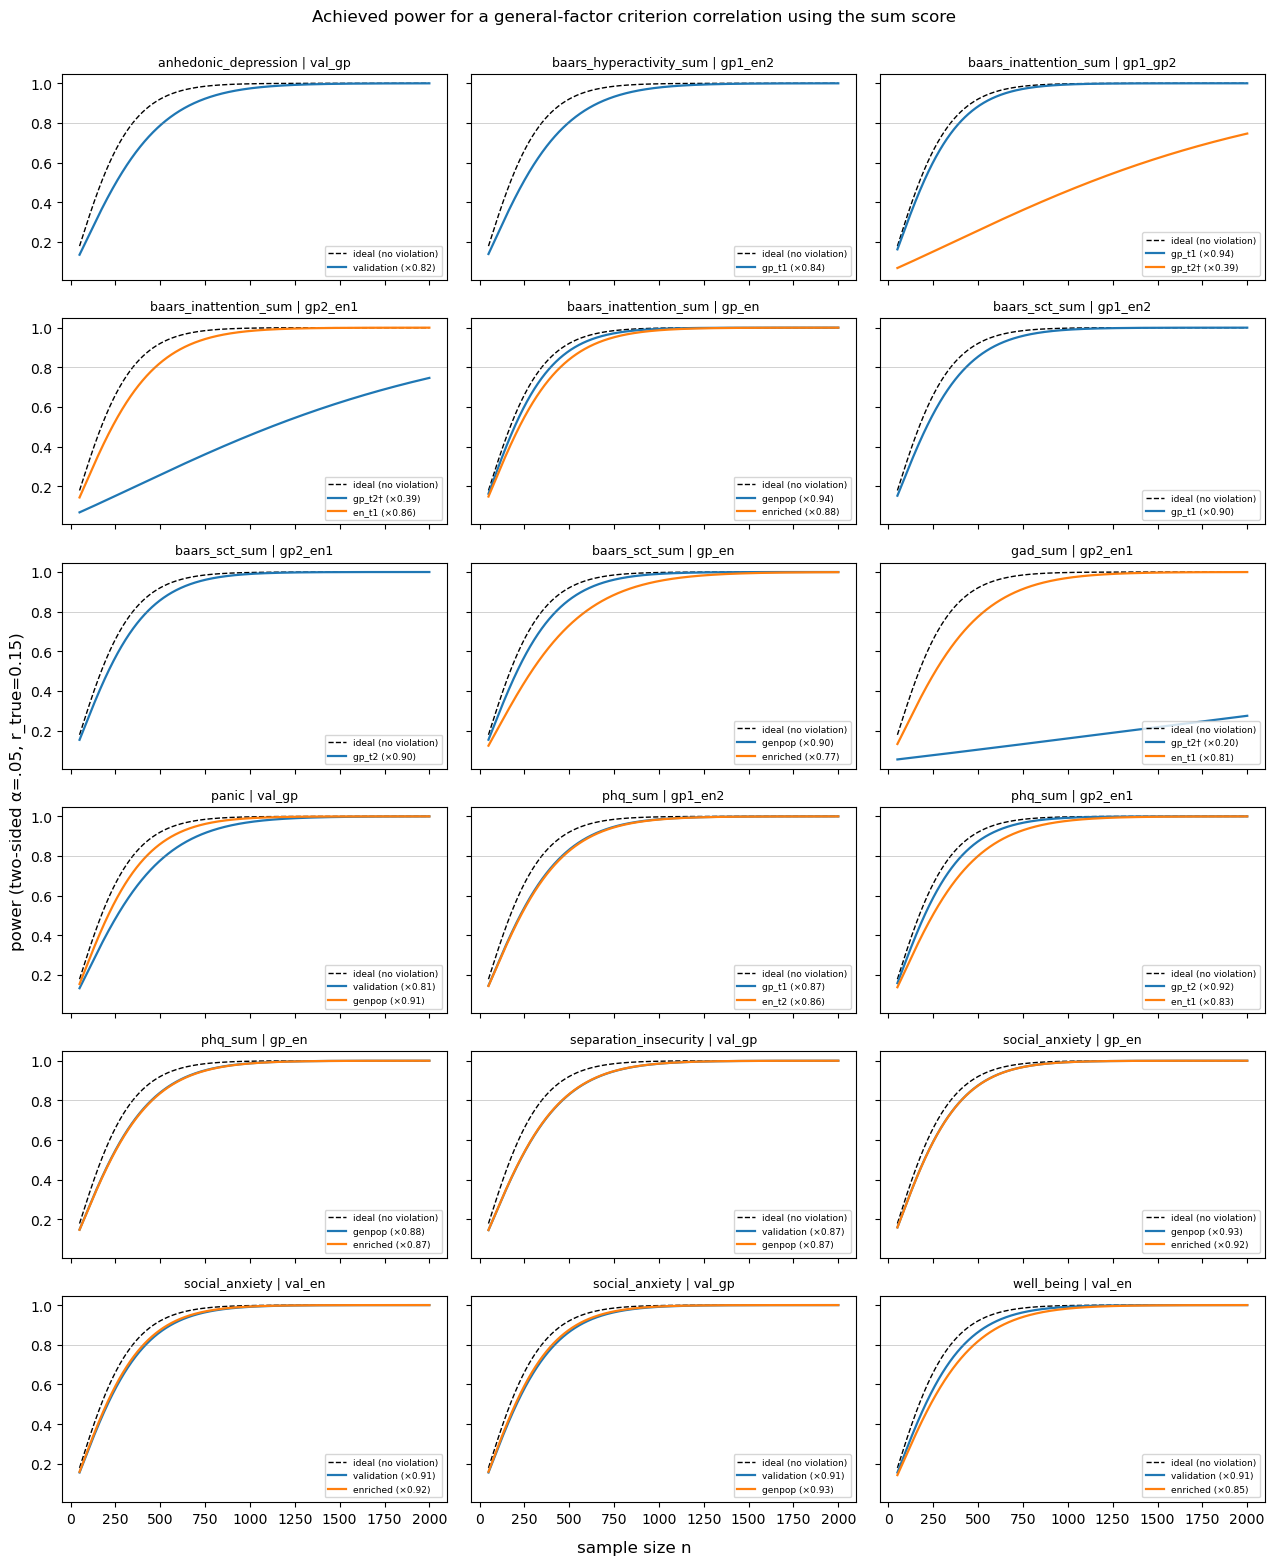

In [13]:
from scipy.stats import norm

def power_r(r_obs, n, alpha=0.05):
    z = np.arctanh(r_obs) * np.sqrt(np.asarray(n) - 3)
    zc = norm.ppf(1 - alpha / 2)
    return norm.cdf(z - zc) + norm.cdf(-z - zc)

def n_for_power(r_obs, target=0.80, alpha=0.05):
    return int(np.ceil(((norm.ppf(1 - alpha / 2) + norm.ppf(target))
                        / np.arctanh(r_obs)) ** 2 + 3))

dim = pd.read_csv(out_dir / 'dimensionality_effect_sizes.csv')
pw = dim[dim.converged == True].copy()
LOW_PHI = pw.phi < 0.30   # general factor undefined -- see caveat
pw['flag'] = np.where(LOW_PHI, '\u2020', '')
R_TRUE = 0.15
ns = np.arange(50, 2001)
combos = sorted(pw.groupby(['scale', 'pair']).groups)
ncol = 3
nrow = int(np.ceil(len(combos) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow),
                         sharex=True, sharey=True)
for ax, (scale, pair) in zip(axes.flat, combos):
    ax.plot(ns, power_r(R_TRUE, ns), 'k--', lw=1, label='ideal (no violation)')
    sub = pw[(pw.scale == scale) & (pw.pair == pair)]
    for _, r in sub.iterrows():
        ax.plot(ns, power_r(R_TRUE * r.attenuation, ns), lw=1.6,
                label=f"{r.group}{r.flag} (\u00d7{r.attenuation:.2f})")
    ax.axhline(0.8, color='grey', lw=0.5, alpha=0.5)
    ax.set_title(f'{scale} | {pair}', fontsize=9)
    ax.legend(fontsize=6.5, loc='lower right')
for ax in axes.flat[len(combos):]:
    ax.set_visible(False)
fig.supxlabel('sample size n')
fig.supylabel(f'power (two-sided \u03b1=.05, r_true={R_TRUE})')
fig.suptitle('Achieved power for a general-factor criterion correlation '
             'using the sum score', y=1.001)
fig.tight_layout()
fig.savefig(out_dir / 'power_curves_r15.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
rows = []
for _, r in pw.iterrows():
    row = dict(scale=r.scale, pair=r.pair, group=r.group + r.flag,
               attenuation=round(r.attenuation, 3))
    for rt in (0.10, 0.15, 0.20):
        row[f'n80_r{int(rt*100)}'] = n_for_power(rt * r.attenuation)
        row[f'extra_r{int(rt*100)}'] = (n_for_power(rt * r.attenuation)
                                        - n_for_power(rt))
    rows.append(row)
ptab = pd.DataFrame(rows).sort_values('attenuation')
ptab.to_csv(out_dir / 'power_required_n.csv', index=False)
print('ideal required n for 80% power: '
      + ', '.join(f'r={rt}: {n_for_power(rt)}' for rt in (0.10, 0.15, 0.20)))
print(ptab.to_string(index=False))

ideal required n for 80% power: r=0.1: 783, r=0.15: 347, r=0.2: 194
                  scale    pair      group  attenuation  n80_r10  extra_r10  n80_r15  extra_r15  n80_r20  extra_r20
                gad_sum gp2_en1     gp_t2†        0.203    19045      18262     8463       8116     4760       4566
  baars_inattention_sum gp2_en1     gp_t2†        0.391     5132       4349     2280       1933     1282       1088
  baars_inattention_sum gp1_gp2     gp_t2†        0.391     5132       4349     2280       1933     1282       1088
          baars_sct_sum   gp_en   enriched        0.767     1332        549      591        244      332        138
                gad_sum gp2_en1      en_t1        0.808     1200        417      533        186      299        105
                  panic  val_gp validation        0.811     1192        409      529        182      297        103
   anhedonic_depression  val_gp validation        0.821     1163        380      516        169      289         95
    